<a href="https://colab.research.google.com/github/laboratoriodecodigos/Colab-Python/blob/main/Colonia_de_Hormigas_Agente_Viajero.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

In [5]:
NUM_CIUDADES = 20

In [2]:
#Establecemos las ubicaciones de las ciudades
ciudades=np.array([
  [10,20],[12,3],
  [1,20],[2,6],
  [5,4],[8,4],
  [5,0],[15,8],
  [1,9],[10,15],
  [11,13],[4,10],
  [7,20],[3,3],
  [5,9],[9,18],
  [4,16],[9,11],
  [2,1],[15,15]])

In [6]:
# MATRIZ DE DISTANCIAS

distancias = np.zeros((NUM_CIUDADES, NUM_CIUDADES))

for i in range(NUM_CIUDADES):
    for j in range(NUM_CIUDADES):
        if i != j:
            x1, y1 = ciudades[i]
            x2, y2 = ciudades[j]
            distancias[i][j] = np.sqrt(
                (x1 - x2) ** 2 +
                (y1 - y2) ** 2
            )

In [7]:
# PARÁMETROS ACO

NUM_HORMIGAS = 50
ITERACIONES = 300

ALPHA = 1.0
BETA = 1.0
RHO = 0.1
Q = 100

In [8]:
# FEROMONAS

feromonas = np.ones(
    (NUM_CIUDADES, NUM_CIUDADES)
)

mejor_ruta = None
mejor_distancia = float('inf')


In [9]:
# DISTANCIA TOTAL

def calcular_distancia(ruta):
    total = 0
    for i in range(len(ruta)-1):
        total += distancias[
            ruta[i]
        ][
            ruta[i+1]
        ]
    total += distancias[
        ruta[-1]
    ][
        ruta[0]
    ]
    return total

In [10]:
# CONSTRUIR RUTA

def construir_ruta(ciudad_inicio):

    ciudad_actual = ciudad_inicio

    ruta = [ciudad_actual]

    no_visitadas = list(
        range(NUM_CIUDADES)
    )

    no_visitadas.remove(
        ciudad_actual
    )

    while no_visitadas:

        # 10% de exploración aleatoria
        if random.random() < 0.10:

            siguiente = random.choice(
                no_visitadas
            )

        else:

            probabilidades = []

            for ciudad in no_visitadas:

                tau = (
                    feromonas[
                        ciudad_actual
                    ][
                        ciudad
                    ] ** ALPHA
                )

                eta = (
                    1.0 /
                    distancias[
                        ciudad_actual
                    ][
                        ciudad
                    ]
                ) ** BETA

                probabilidades.append(
                    tau * eta
                )

            probabilidades = np.array(
                probabilidades
            )

            probabilidades = (
                probabilidades /
                probabilidades.sum()
            )

            siguiente = int(
                np.random.choice(
                    no_visitadas,
                    p=probabilidades
                )
            )

        ruta.append(siguiente)

        no_visitadas.remove(
            siguiente
        )

        ciudad_actual = siguiente

    return ruta


In [15]:
#ACO

distancia_historial = [] # Initialize the history list

for it in range(ITERACIONES):

    rutas = []
    distancias_rutas = []

    # Las hormigas empiezan en
    # ciudades diferentes
    ciudades_inicio = np.random.permutation(
        NUM_CIUDADES
    )

    for i in range(NUM_HORMIGAS):

        ciudad_inicio = int(
            ciudades_inicio[
                i % NUM_CIUDADES
            ]
        )

        ruta = construir_ruta(
            ciudad_inicio
        )

        distancia = calcular_distancia(
            ruta
        )

        rutas.append(ruta)
        distancias_rutas.append(
            distancia
        )

        if distancia < mejor_distancia:
            mejor_distancia = distancia
            mejor_ruta = ruta.copy()

    distancia_historial.append(mejor_distancia) # Store the best distance for this iteration

    # EVAPORACIÓN

    feromonas *= (1 - RHO)


    # DEPÓSITO DE FEROMONAS

    for ruta, distancia in zip(
        rutas,
        distancias_rutas
    ):

        deposito = Q / distancia

        for i in range(
            NUM_CIUDADES - 1
        ):

            a = ruta[i]
            b = ruta[i + 1]

            feromonas[a][b] += deposito
            feromonas[b][a] += deposito

        a = ruta[-1]
        b = ruta[0]

        feromonas[a][b] += deposito
        feromonas[b][a] += deposito

    if (it + 1) % 20 == 0:
        print(
            f"Iteración {it+1:3d} "
            f"Mejor distancia: "
            f"{mejor_distancia:.2f}"
        )


Iteración  20 Mejor distancia: 81.30
Iteración  40 Mejor distancia: 81.30
Iteración  60 Mejor distancia: 81.30
Iteración  80 Mejor distancia: 81.30
Iteración 100 Mejor distancia: 80.78
Iteración 120 Mejor distancia: 80.78
Iteración 140 Mejor distancia: 80.78
Iteración 160 Mejor distancia: 79.00
Iteración 180 Mejor distancia: 79.00
Iteración 200 Mejor distancia: 79.00
Iteración 220 Mejor distancia: 79.00
Iteración 240 Mejor distancia: 79.00
Iteración 260 Mejor distancia: 79.00
Iteración 280 Mejor distancia: 79.00
Iteración 300 Mejor distancia: 79.00


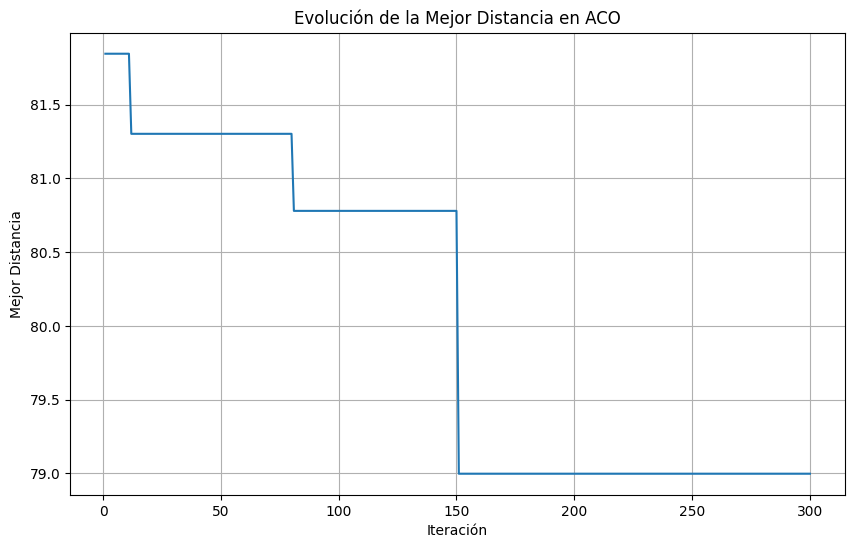

In [16]:
if 'distancia_historial' in locals() and len(distancia_historial) > 0:
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(distancia_historial) + 1), distancia_historial)
    plt.title('Evolución de la Mejor Distancia en ACO')
    plt.xlabel('Iteración')
    plt.ylabel('Mejor Distancia')
    plt.grid(True)
    plt.show()
else:
    print("El historial de distancias no está disponible. Asegúrate de ejecutar el algoritmo ACO (celda HsVgC-p2SXNN) primero para recopilar los datos.")

In [13]:
# RESULTADOS

print("\nMejor ruta:")
mejor_ruta = [int(i) for i in mejor_ruta]
print(mejor_ruta)

print(
    "Distancia total:",
    round(mejor_distancia, 2)
)


Mejor ruta:
[13, 3, 8, 11, 14, 17, 10, 9, 15, 0, 12, 2, 16, 19, 7, 1, 5, 4, 18, 6]
Distancia total: 81.85


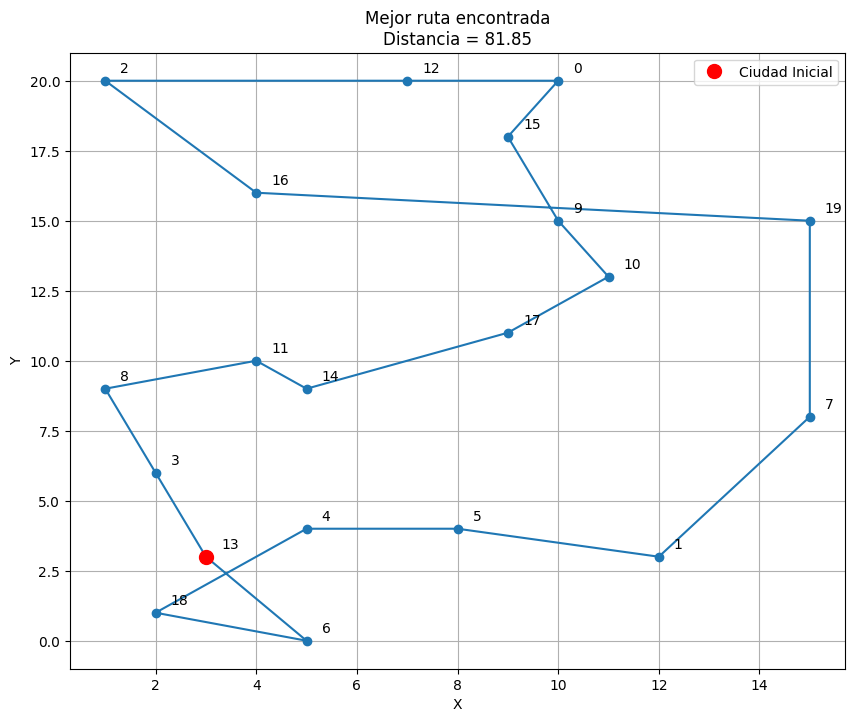

In [14]:
# GRAFICAR RUTA

ruta = mejor_ruta + [mejor_ruta[0]]

x = [ciudades[i][0] for i in ruta]
y = [ciudades[i][1] for i in ruta]

plt.figure(figsize=(10, 8))
plt.plot(x,y,'-o')

# Poner en rojo la ciudad inicial
start_city_index = mejor_ruta[0]
start_x = ciudades[start_city_index][0]
start_y = ciudades[start_city_index][1]
plt.plot(start_x, start_y, 'o', color='red',
         markersize=10, label='Ciudad Inicial')

for i, (cx, cy) in enumerate(ciudades):
    plt.text(cx + 0.3,cy + 0.3,str(i))

plt.title(
    f'Mejor ruta encontrada\n'
    f'Distancia = {mejor_distancia:.2f}'
)

plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.legend()
plt.show()